In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error
from statsmodels.tsa.stattools import pacf
from xgboost import XGBRegressor
import re
from sklearn.cluster import KMeans

In [2]:
plt.style.use("seaborn-whitegrid")
plt.rc("figure", autolayout=True, figsize=(11, 5))
plt.rc(
    "axes",
    labelweight="bold",
    labelsize="large",
    titleweight="bold",
    titlesize=14,
    titlepad=10,
)
plot_params = dict(
    color="0.75",
    style=".-",
    markeredgecolor="0.25",
    markerfacecolor="0.25",
    legend=False,
)
%config InlineBackend.figure_format = 'retina'

In [3]:
a = pd.read_csv("C:/Users/as comp/Downloads/AT_2020.csv")
b = pd.read_csv("C:/Users/as comp/Downloads/AT_2021.csv")
c = pd.read_csv("C:/Users/as comp/Downloads/AT_2022.csv")
d = pd.read_csv("C:/Users/as comp/Downloads/AT_2023.csv")
e = pd.read_csv("C:/Users/as comp/Downloads/AT_2024.csv")

In [4]:
data = pd.concat([a,b,c,d,e], axis = 0)

In [5]:
data.describe()

,Actual Total Load (MW),Day-ahead Total Load Forecast (MW)
count,175392.000000,175392.000000
mean,6899.231301,6806.978334
std,1320.416262,1243.473008
min,4009.200000,3964.000000
25%,5842.000000,5792.000000
50%,6854.800000,6784.000000
75%,7834.000000,7704.000000
max,10580.400000,10008.000000


In [6]:
data.index = data['MTU (CET/CEST)'].astype(str).str.split(" - ").str[0]
data.index.rename('datetime', inplace = True)
data.drop(['Area'], axis=1, inplace = True)
data.drop(['MTU (CET/CEST)'], axis = 1, inplace = True)

In [7]:
data.index = data.index.str.replace(r"\s*\(.*?\)", "", regex=True)

In [8]:
data.index = pd.to_datetime(data.index)

In [9]:
data.head()

,Actual Total Load (MW),Day-ahead Total Load Forecast (MW)
datetime,,
2020-01-01 00:00:00,6058.8,5912.0
2020-01-01 00:15:00,6000.8,5796.0
2020-01-01 00:30:00,5936.4,5696.0
2020-01-01 00:45:00,5871.2,5604.0
2020-01-01 01:00:00,5873.6,5588.0


<AxesSubplot:title={'center':'Five Years Load Plot'}, xlabel='datetime'>

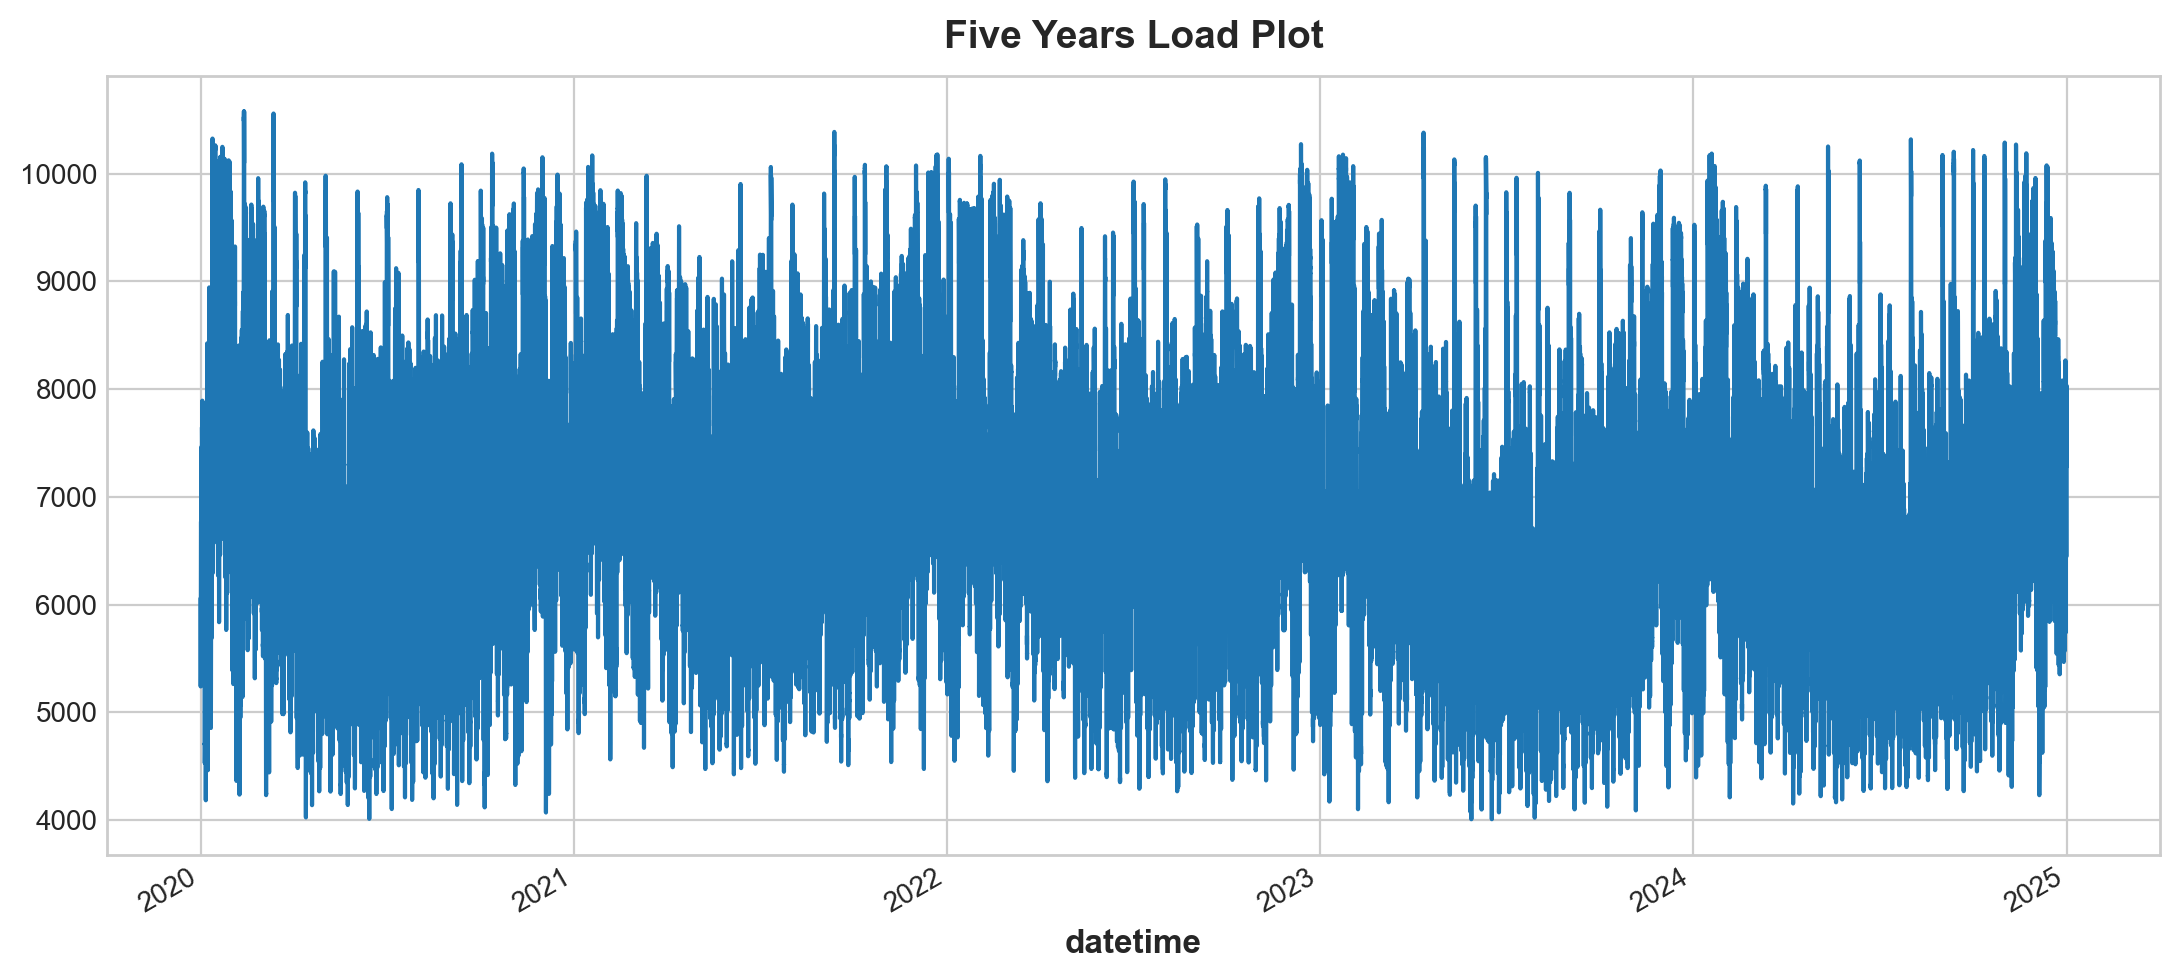

In [28]:
plt.figure()
data['Actual Total Load (MW)'].plot(title='Five Years Load Plot')

<AxesSubplot:title={'center':'Five Years Load Plot'}, xlabel='datetime'>

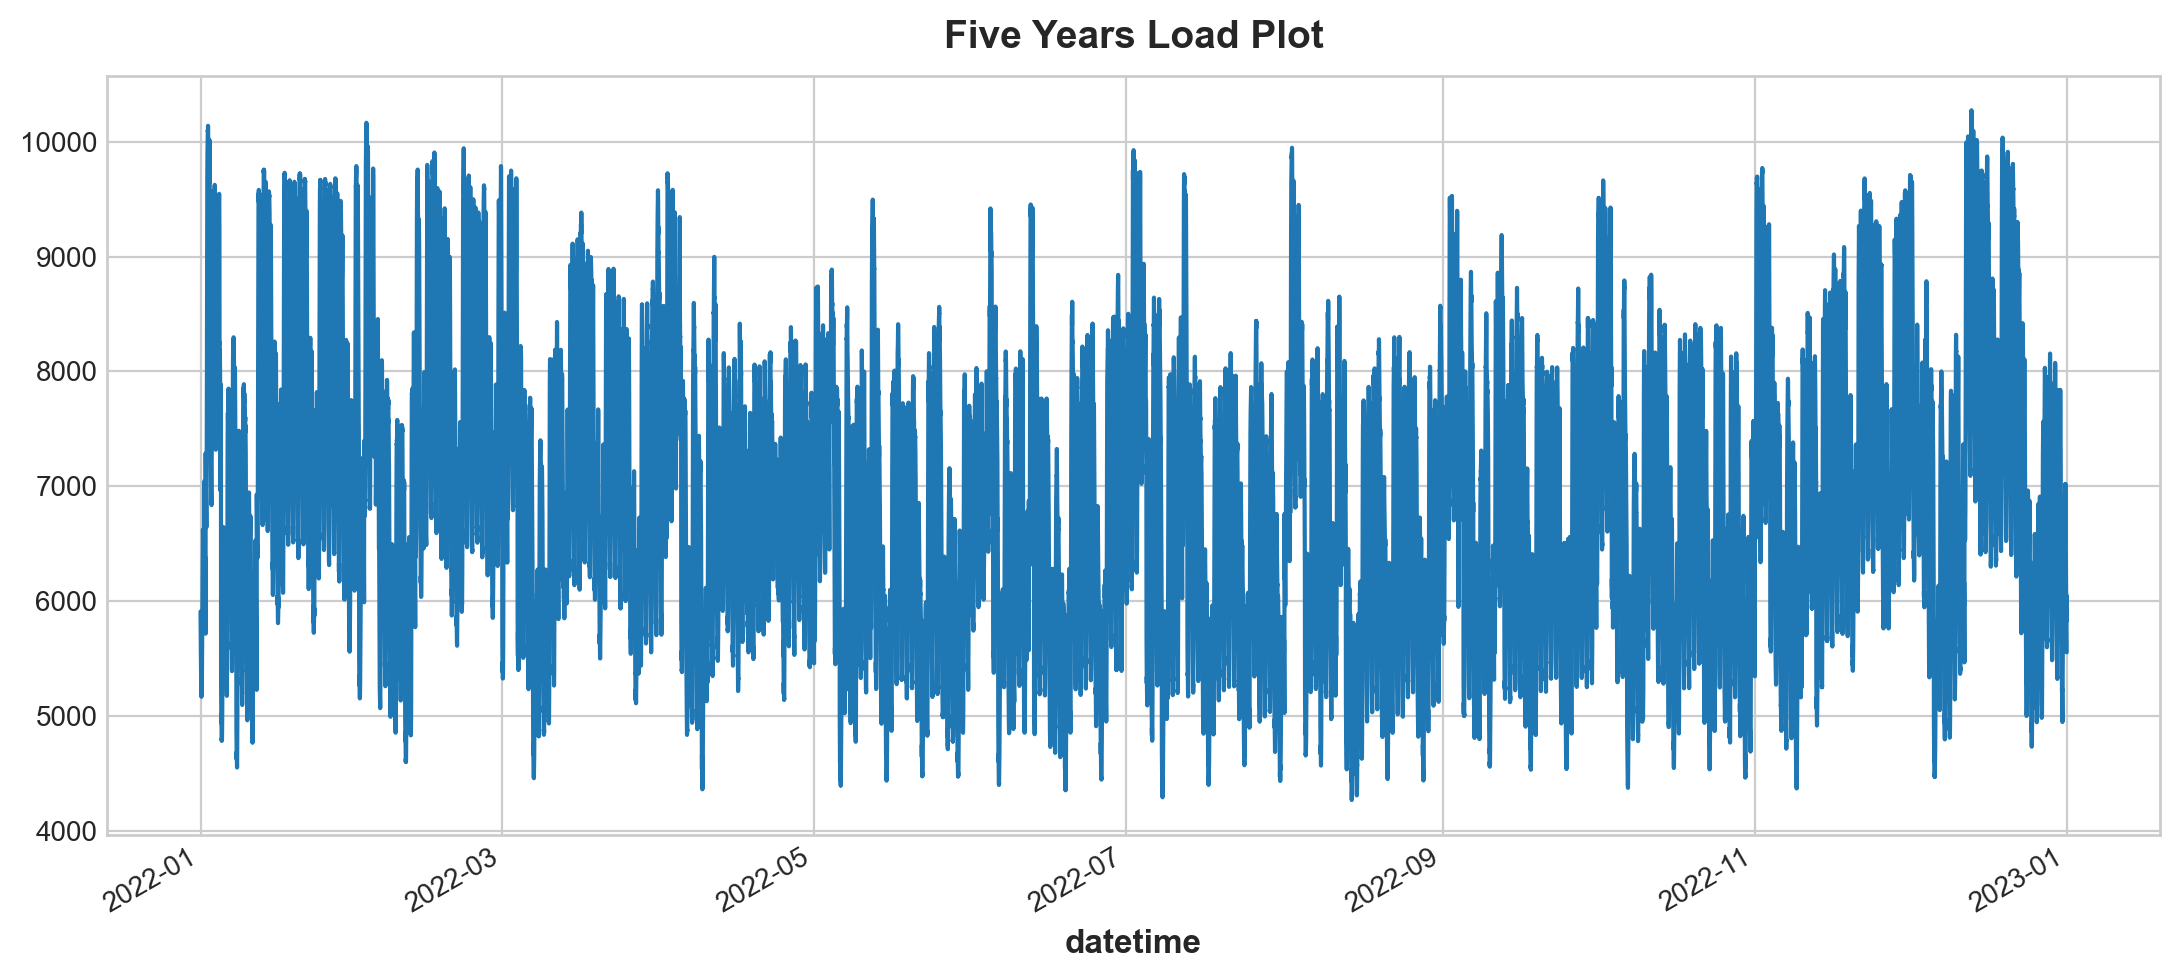

In [29]:
plt.figure()
data.loc['2022', 'Actual Total Load (MW)'].plot(title='Five Years Load Plot')

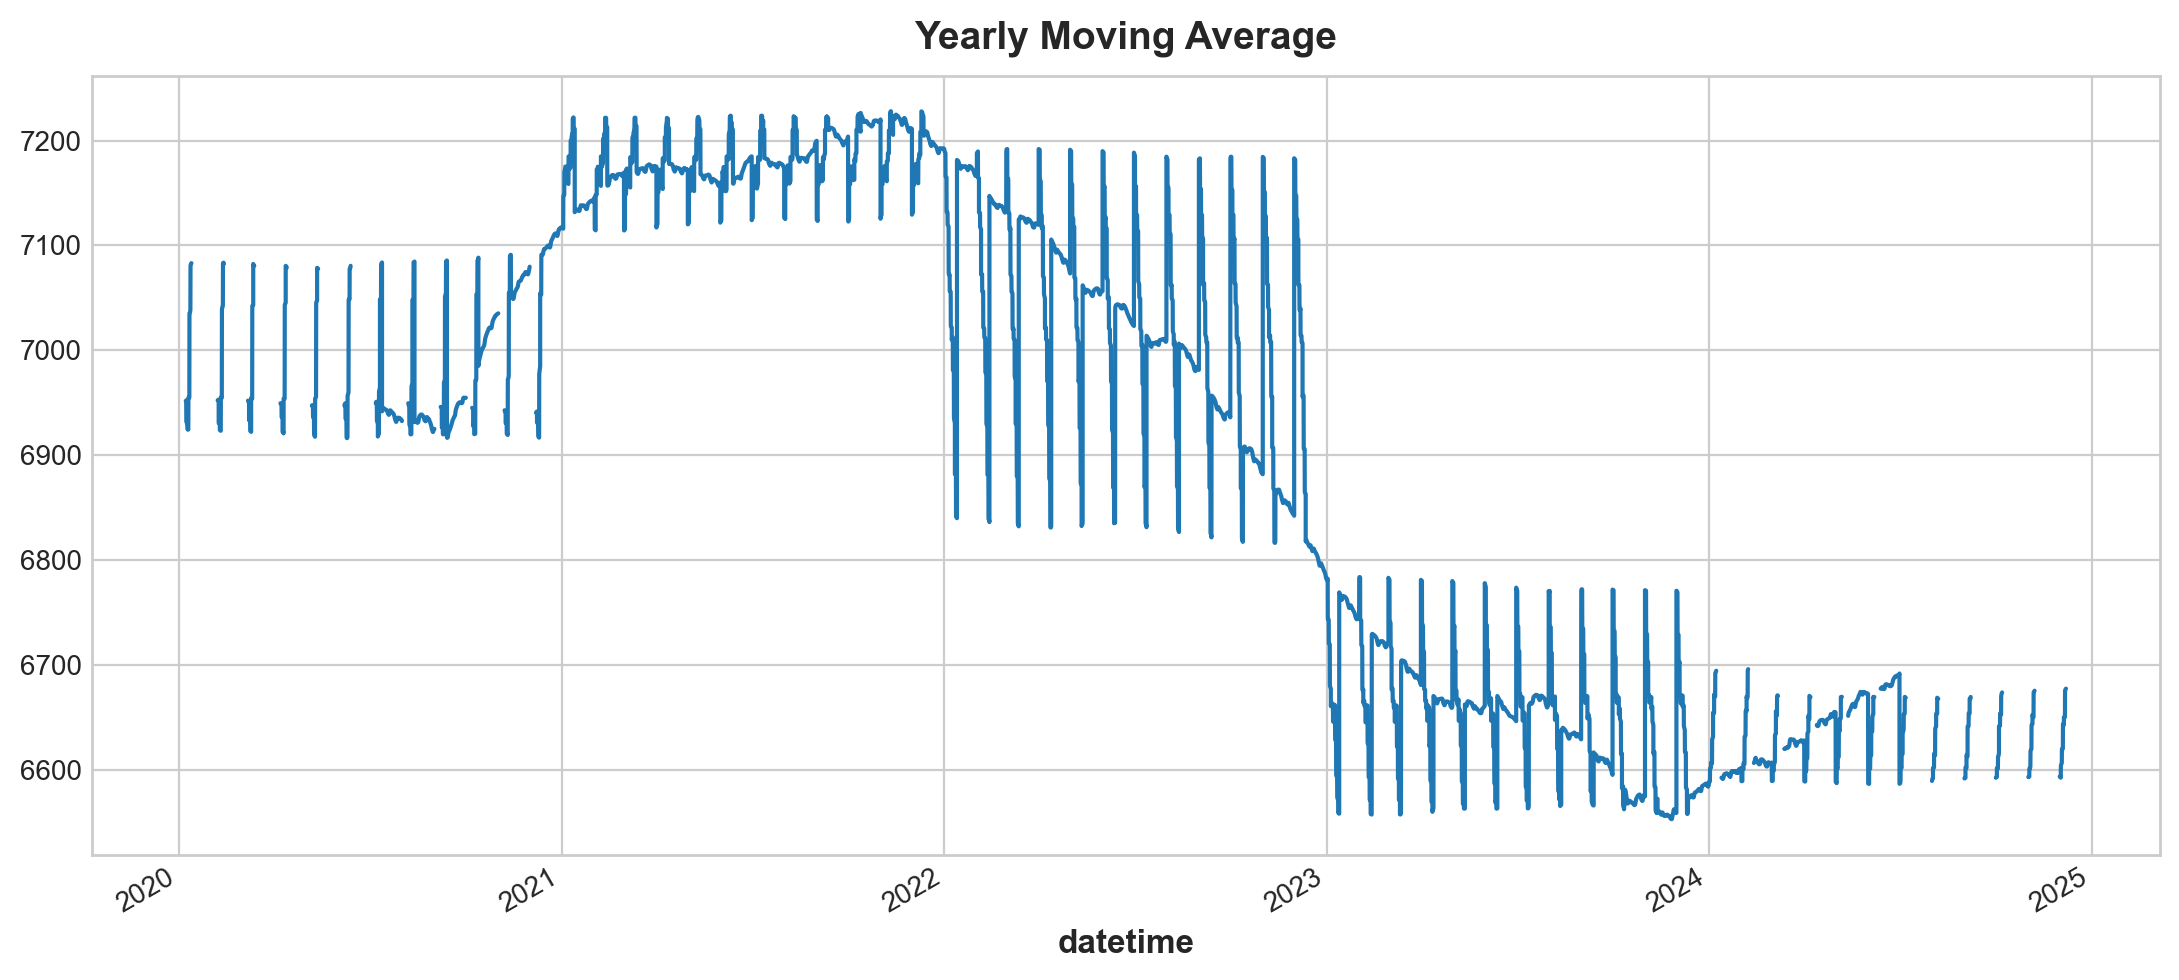

In [33]:
y_ma = data['Actual Total Load (MW)'].rolling(24*365*4,center=True).mean()


# Plot
ax = y_ma.plot()
ax.set_title("Yearly Moving Average");

In [9]:
from scipy.signal import periodogram

def plot_periodogram(ts, detrend='linear', ax=None):
    # Sampling frequency: 24 hours per day * 365 days per year
    fs = 24 * 4 * 365  # samples per year

    # Compute the periodogram
    freq, spectrum = periodogram(
        ts,
        fs=fs,
        detrend=detrend,
        window="boxcar",
        scaling='spectrum'
    )

    # Plot setup
    if ax is None:
        _, ax = plt.subplots(figsize=(10, 5))

    ax.step(freq, spectrum, color="darkviolet", linewidth=1.5)
    ax.set_xscale("log")

    # X-axis ticks (in cycles per year)
    ax.set_xticks([1, 2, 4, 12, 52, 365, 730])
    ax.set_xticklabels(
        [
            "Annual (1)",
            "Semiannual (2)",
            "Quarterly (4)",
            "Monthly (12)",
            "Weekly (52)",
            "Daily (365)",
            "Twice Daily (730)"
        ],
        rotation=30
    )

    # Labels and title
    ax.set_ylabel("Strength", fontsize=11)
    ax.set_title("Periodogram (Hourly Data over 5 Years)", fontsize=13)
    ax.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))

    # Cosmetic improvements
    ax.grid(True, which='both', linestyle='--', alpha=0.4)
    plt.tight_layout()
    return ax



<AxesSubplot:title={'center':'Periodogram (Hourly Data over 5 Years)'}, ylabel='Strength'>

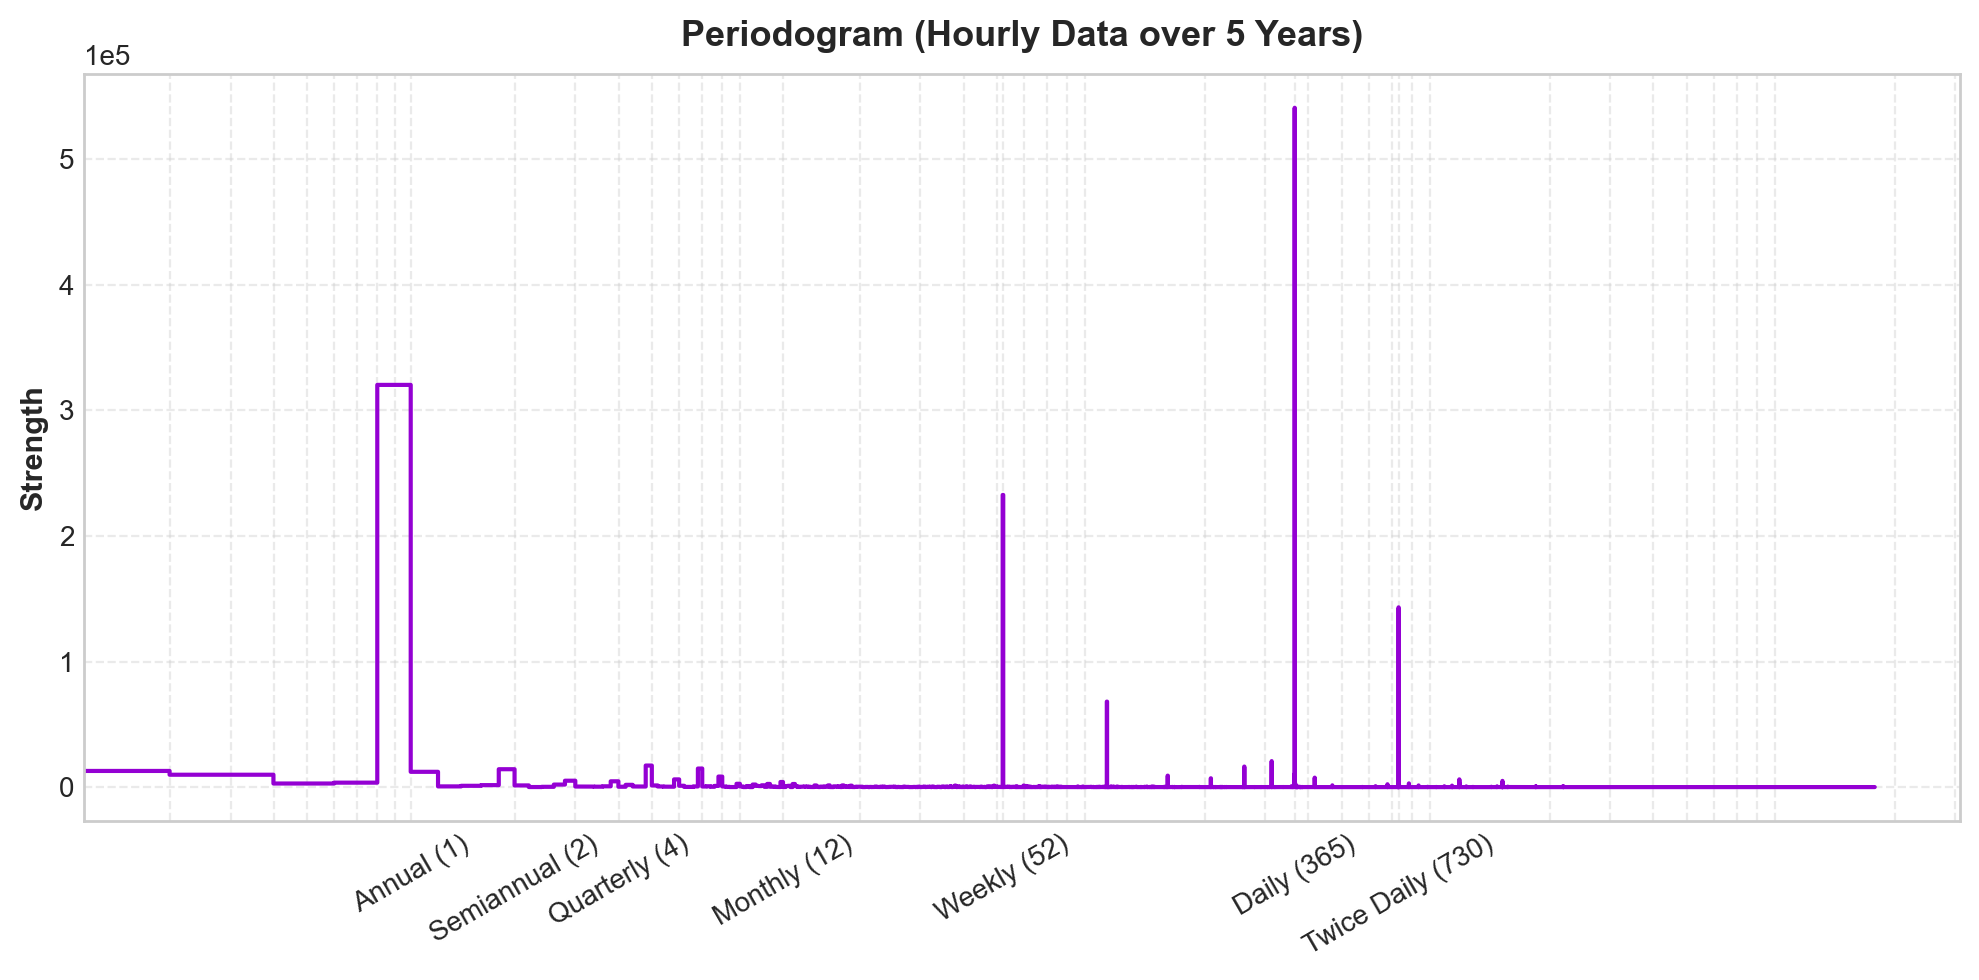

In [10]:
plot_periodogram(data['Actual Total Load (MW)'])

In [227]:
from statsmodels.tsa.deterministic import DeterministicProcess, CalendarFourier

# Create Fourier terms matching your periodogram peaks
daily = CalendarFourier(freq='D', order=3)      # captures 24h, 12h, 8h cycles
weekly = CalendarFourier(freq='W', order=2)     # weekly + harmonic
annual = CalendarFourier(freq='A', order=6)     # annual + semiannual + quarterly + smaller peaks

dp = DeterministicProcess(
    index=data.index,
    constant=True,      # intercept
    order=1,            # linear trend
    seasonal=False,     # you already use Fourier → don't want dummy explosion
    additional_terms=[daily, weekly, annual],
    drop=True
)

X = dp.in_sample()


In [216]:
X

,const,trend,"sin(1,freq=D)","cos(1,freq=D)","sin(2,freq=D)","cos(2,freq=D)","sin(3,freq=D)","cos(3,freq=D)","sin(1,freq=W-SUN)","cos(1,freq=W-SUN)",...,"sin(2,freq=A-DEC)","cos(2,freq=A-DEC)","sin(3,freq=A-DEC)","cos(3,freq=A-DEC)","sin(4,freq=A-DEC)","cos(4,freq=A-DEC)","sin(5,freq=A-DEC)","cos(5,freq=A-DEC)","sin(6,freq=A-DEC)","cos(6,freq=A-DEC)"
datetime,,,,,,,,,,,,,,,,,,,,,
2020-01-01 00:00:00,1.0,1.0,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.974928,-0.222521,...,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000
2020-01-01 00:15:00,1.0,2.0,0.065403,0.997859,0.130526,0.991445,0.195090,0.980785,0.972805,-0.231627,...,0.000358,1.000000,0.000536,1.000000,0.000715,1.000000,0.000894,1.000000,0.001073,0.999999
2020-01-01 00:30:00,1.0,3.0,0.130526,0.991445,0.258819,0.965926,0.382683,0.923880,0.970597,-0.240712,...,0.000715,1.000000,0.001073,0.999999,0.001431,0.999999,0.001788,0.999998,0.002146,0.999998
2020-01-01 00:45:00,1.0,4.0,0.195090,0.980785,0.382683,0.923880,0.555570,0.831470,0.968304,-0.249776,...,0.001073,0.999999,0.001609,0.999999,0.002146,0.999998,0.002682,0.999996,0.003219,0.999995
2020-01-01 01:00:00,1.0,5.0,0.258819,0.965926,0.500000,0.866025,0.707107,0.707107,0.965926,-0.258819,...,0.001431,0.999999,0.002146,0.999998,0.002861,0.999996,0.003576,0.999994,0.004292,0.999991
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31 22:45:00,1.0,175388.0,-0.321439,0.946930,-0.608761,0.793353,-0.831470,0.555570,0.984262,-0.176717,...,-0.001788,0.999998,-0.002682,0.999996,-0.003576,0.999994,-0.004471,0.999990,-0.005365,0.999986
2024-12-31 23:00:00,1.0,175389.0,-0.258819,0.965926,-0.500000,0.866025,-0.707107,0.707107,0.982566,-0.185912,...,-0.001431,0.999999,-0.002146,0.999998,-0.002861,0.999996,-0.003576,0.999994,-0.004292,0.999991
2024-12-31 23:15:00,1.0,175390.0,-0.195090,0.980785,-0.382683,0.923880,-0.555570,0.831470,0.980785,-0.195090,...,-0.001073,0.999999,-0.001609,0.999999,-0.002146,0.999998,-0.002682,0.999996,-0.003219,0.999995


In [210]:
y=data['Actual Total Load (MW)']

In [211]:
def make_lags(ts, lagfirst, laglast):
    return pd.concat(
        {
            f'y_lag_{i}': ts.shift(i)
            for i in range(lagfirst, laglast + 1)
        },
        axis=1)

In [225]:
X_train = X.iloc[:-96*30*9]
X_test = X.iloc[-96*30*9:]
y_train = y.iloc[:-96*30*9]
y_test = y.iloc[-96*30*9:]

In [226]:
X_train

,const,trend,"sin(1,freq=D)","cos(1,freq=D)","sin(2,freq=D)","cos(2,freq=D)","sin(3,freq=D)","cos(3,freq=D)","sin(1,freq=W-SUN)","cos(1,freq=W-SUN)",...,"sin(2,freq=A-DEC)","cos(2,freq=A-DEC)","sin(3,freq=A-DEC)","cos(3,freq=A-DEC)","sin(4,freq=A-DEC)","cos(4,freq=A-DEC)","sin(5,freq=A-DEC)","cos(5,freq=A-DEC)","sin(6,freq=A-DEC)","cos(6,freq=A-DEC)"
datetime,,,,,,,,,,,,,,,,,,,,,
2020-01-01 00:00:00,1.0,1.0,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.974928,-0.222521,...,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000
2020-01-01 00:15:00,1.0,2.0,0.065403,0.997859,0.130526,0.991445,0.195090,0.980785,0.972805,-0.231627,...,0.000358,1.000000,0.000536,1.000000,0.000715,1.000000,0.000894,1.000000,0.001073,0.999999
2020-01-01 00:30:00,1.0,3.0,0.130526,0.991445,0.258819,0.965926,0.382683,0.923880,0.970597,-0.240712,...,0.000715,1.000000,0.001073,0.999999,0.001431,0.999999,0.001788,0.999998,0.002146,0.999998
2020-01-01 00:45:00,1.0,4.0,0.195090,0.980785,0.382683,0.923880,0.555570,0.831470,0.968304,-0.249776,...,0.001073,0.999999,0.001609,0.999999,0.002146,0.999998,0.002682,0.999996,0.003219,0.999995
2020-01-01 01:00:00,1.0,5.0,0.258819,0.965926,0.500000,0.866025,0.707107,0.707107,0.965926,-0.258819,...,0.001431,0.999999,0.002146,0.999998,0.002861,0.999996,0.003576,0.999994,0.004292,0.999991
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-05-04 23:45:00,1.0,149468.0,-0.065403,0.997859,-0.130526,0.991445,-0.195090,0.980785,-0.787627,0.616153,...,-0.912700,-0.408631,0.153360,0.988170,0.745914,-0.666042,-0.964571,-0.263825,0.303093,0.952961
2024-06-04 00:00:00,1.0,149469.0,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.781831,0.623490,...,-0.819972,0.572404,0.991723,-0.128398,-0.938710,-0.344707,0.672949,0.739689,-0.254671,-0.967028
2024-06-04 00:15:00,1.0,149470.0,0.065403,0.997859,0.130526,0.991445,0.195090,0.980785,0.787627,0.616153,...,-0.819767,0.572697,0.991654,-0.128930,-0.938957,-0.344036,0.673610,0.739087,-0.255709,-0.966754


In [228]:
idx_train, idx_test = train_test_split(
    data.index, test_size=0.05, shuffle=False,
)

X_train, X_test = X.loc[idx_train, :], X.loc[idx_test, :]
y_train, y_test = y.loc[idx_train], y.loc[idx_test]

In [230]:
X_test

,const,trend,"sin(1,freq=D)","cos(1,freq=D)","sin(2,freq=D)","cos(2,freq=D)","sin(3,freq=D)","cos(3,freq=D)","sin(1,freq=W-SUN)","cos(1,freq=W-SUN)",...,"sin(2,freq=A-DEC)","cos(2,freq=A-DEC)","sin(3,freq=A-DEC)","cos(3,freq=A-DEC)","sin(4,freq=A-DEC)","cos(4,freq=A-DEC)","sin(5,freq=A-DEC)","cos(5,freq=A-DEC)","sin(6,freq=A-DEC)","cos(6,freq=A-DEC)"
datetime,,,,,,,,,,,,,,,,,,,,,
2024-01-10 16:30:00,1.0,166623.0,-0.923880,-0.382683,0.707107,-0.707107,0.382683,0.923880,0.666347,-0.745642,...,0.326515,0.945192,0.478478,0.878099,0.617238,0.786776,0.738966,0.673742,0.840303,0.542117
2024-01-10 16:45:00,1.0,166624.0,-0.946930,-0.321439,0.608761,-0.793353,0.555570,0.831470,0.659346,-0.751840,...,0.326853,0.945075,0.478949,0.877843,0.617801,0.786334,0.739569,0.673081,0.840884,0.541215
2024-01-10 17:00:00,1.0,166625.0,-0.965926,-0.258819,0.500000,-0.866025,0.707107,0.707107,0.652287,-0.757972,...,0.327191,0.944958,0.479420,0.877585,0.618363,0.785892,0.740170,0.672420,0.841464,0.540313
2024-01-10 17:15:00,1.0,166626.0,-0.980785,-0.195090,0.382683,-0.923880,0.831470,0.555570,0.645172,-0.764037,...,0.327529,0.944841,0.479891,0.877328,0.618925,0.785450,0.740771,0.671758,0.842044,0.539409
2024-01-10 17:30:00,1.0,166627.0,-0.991445,-0.130526,0.258819,-0.965926,0.923880,0.382683,0.638000,-0.770036,...,0.327867,0.944724,0.480362,0.877071,0.619487,0.785007,0.741371,0.671095,0.842622,0.538506
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31 22:45:00,1.0,175388.0,-0.321439,0.946930,-0.608761,0.793353,-0.831470,0.555570,0.984262,-0.176717,...,-0.001788,0.999998,-0.002682,0.999996,-0.003576,0.999994,-0.004471,0.999990,-0.005365,0.999986
2024-12-31 23:00:00,1.0,175389.0,-0.258819,0.965926,-0.500000,0.866025,-0.707107,0.707107,0.982566,-0.185912,...,-0.001431,0.999999,-0.002146,0.999998,-0.002861,0.999996,-0.003576,0.999994,-0.004292,0.999991
2024-12-31 23:15:00,1.0,175390.0,-0.195090,0.980785,-0.382683,0.923880,-0.555570,0.831470,0.980785,-0.195090,...,-0.001073,0.999999,-0.001609,0.999999,-0.002146,0.999998,-0.002682,0.999996,-0.003219,0.999995


In [100]:
import statsmodels.api as sm



model = sm.tsa.statespace.SARIMAX(
    y_train,
    exog=X_train,
    order=(2,1,1),
#    seasonal_order=(1,1,1,96),
    enforce_stationarity=False,
    enforce_invertibility=False
)

result = model.fit()
print(result.summary())


C:\Users\as comp\miniconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\as comp\miniconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\as comp\miniconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\as comp\miniconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                                 SARIMAX Results                                  
Dep. Variable:     Actual Total Load (MW)   No. Observations:               166654
Model:                   SARIMAX(2, 1, 1)   Log Likelihood             -920410.368
Date:                    Tue, 02 Dec 2025   AIC                        1840876.735
Time:                            19:27:22   BIC                        1841157.397
Sample:                                 0   HQIC                       1840960.000
                                 - 166654                                         
Covariance Type:                      opg                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const              2.434e-08   1.03e+04   2.37e-12      1.000   -2.01e+04    2.01e+04
trend                -0.1465      0.350     -0.418      0.676      -0.833     

In [109]:
y_fit = result.fittedvalues  # in-sample predictions

In [105]:
n_forecast = len(y_test)

forecast = result.get_forecast(steps=n_forecast, exog=X_test)  # if exogenous vars
y_pred = forecast.predicted_mean
y_pred.index = y_test.index  # align index

C:\Users\as comp\miniconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\as comp\miniconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [510]:
X1 = make_lags(data.loc[idx_train, 'Actual Total Load (MW)'], 6*4+1, 24*4+8).fillna(0.0)
X2 = make_lags(data.loc[idx_train, 'Actual Total Load (MW)'], 48*4+1, 48*4+8).fillna(0.0)
#X3 = make_lags(data.loc[idx_train, 'Actual Total Load (MW)'], 72*4+1, 72*4+8).fillna(0.0)

In [511]:
Y = make_lags(data.loc[idx_train, 'Actual Total Load (MW)'], -24*4+1, 0).fillna(0.0)

In [512]:
x1 = make_lags(data.loc[idx_test, 'Actual Total Load (MW)'], 6*4+1, 24*4+8).fillna(0.0)
x2 = make_lags(data.loc[idx_test, 'Actual Total Load (MW)'], 48*4+1, 48*4+8).fillna(0.0)
#x3 = make_lags(data.loc[idx_test, 'Actual Total Load (MW)'], 72*4+1, 72*4+8).fillna(0.0)

In [513]:
X_train = pd.concat([X_train,X1,X2], axis = 1).fillna(0.0)
X_test = pd.concat([X_test,x1,x2], axis = 1).fillna(0.0)
y_train = Y.fillna(0.0)

In [213]:
from sklearn.linear_model import LinearRegression
#from sklearn.multioutput import MultiOutputRegressor
#from xgboost import XGBRegressor
model = LinearRegression()
_ = model.fit(X_train, y_train)

#y_fit = pd.Series(model.predict(X_train), index=X_train.index)
y_pred = pd.Series(model.predict(X_test), index=X_test.index)



In [520]:
# 1. select first row of every day (every 96 steps)
y_fit_daily = y_fit.iloc[::96]
y_pred_daily = y_pred.iloc[::96]

# 2. create time offsets for each 96-step 15-minute forecast
freq = '15T'
horizon = y_fit.shape[1]
offsets = pd.timedelta_range(start='0T', periods=horizon, freq=freq)

# 3. convert rows into a timestamp-indexed Series
def expand_forecast(df):
    series_list = []
    for ts, row in df.iterrows():
        idx = ts + offsets
        s = pd.Series(row.values, index=idx)
        series_list.append(s)
    return pd.concat(series_list)

# 4. expanded series
y_fit = expand_forecast(y_fit_daily)
y_pred = expand_forecast(y_pred_daily)


In [521]:
y_train = y_train.y_lag_0

In [522]:
y_train, y_fit = y_train.align(y_fit, join='inner', axis = 0)

In [523]:
y_test, y_pred = y_test.align(y_pred, join='inner', axis = 0)

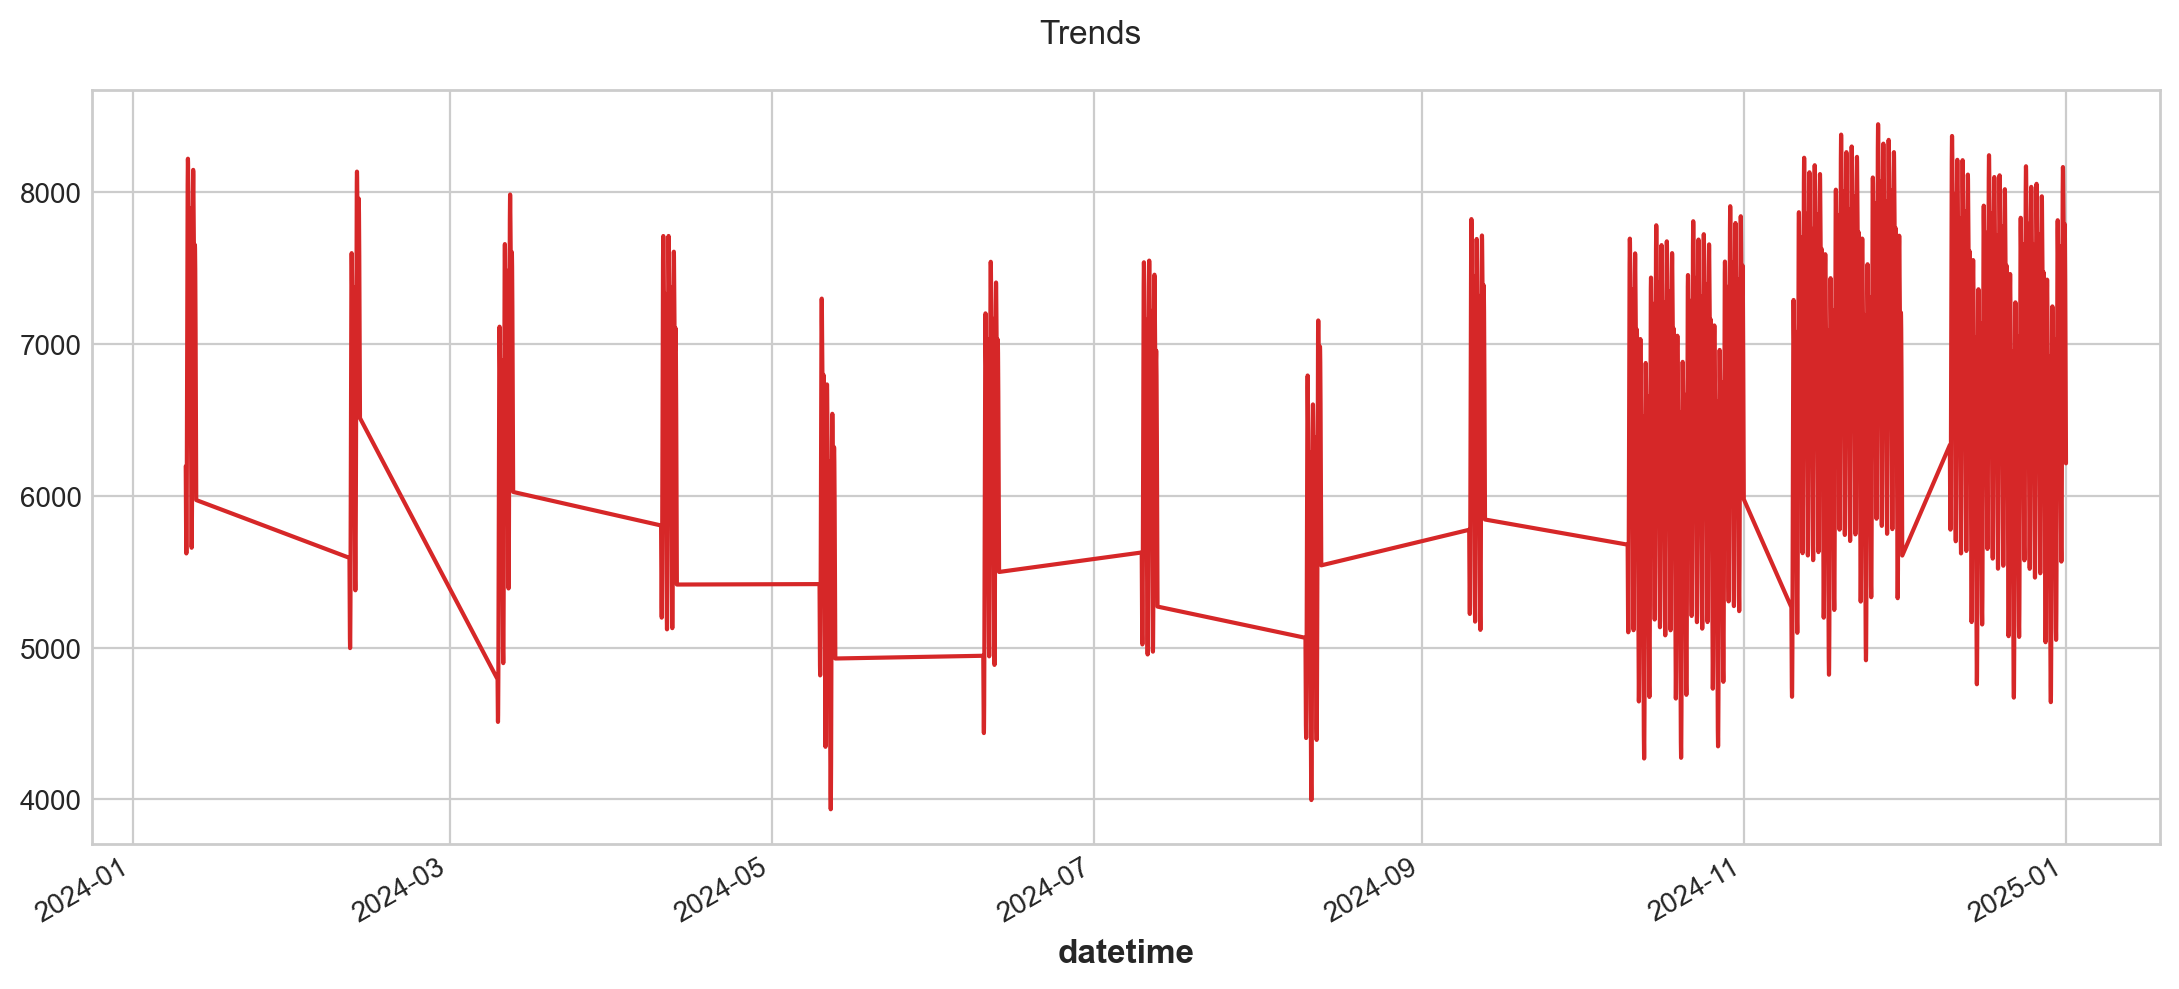

In [214]:
#axs = y_train.plot(color='0.25', subplots=True, sharex=True)
#axs = y_test.plot(color='0.25', subplots=True, sharex=True, )
#axs = y_fit.plot(color='C0', subplots=True, sharex=True, ax=axs)
axs = y_pred.plot(color='C3', subplots=True, sharex=True)
for ax in axs: ax.legend([])
_ = plt.suptitle("Trends")

In [215]:
y_pred

datetime
2024-03-10 01:00:00    4790.554188
2024-03-10 01:15:00    4724.862690
2024-03-10 01:30:00    4666.034415
2024-03-10 01:45:00    4615.061198
2024-03-10 02:00:00    4572.949456
                          ...     
2024-12-31 22:45:00    6577.460918
2024-12-31 23:00:00    6485.556383
2024-12-31 23:15:00    6394.071763
2024-12-31 23:30:00    6303.473063
2024-12-31 23:45:00    6214.269181
Length: 8640, dtype: float64

In [218]:
X_test

,const,trend,"sin(1,freq=D)","cos(1,freq=D)","sin(2,freq=D)","cos(2,freq=D)","sin(3,freq=D)","cos(3,freq=D)","sin(1,freq=W-SUN)","cos(1,freq=W-SUN)",...,"sin(2,freq=A-DEC)","cos(2,freq=A-DEC)","sin(3,freq=A-DEC)","cos(3,freq=A-DEC)","sin(4,freq=A-DEC)","cos(4,freq=A-DEC)","sin(5,freq=A-DEC)","cos(5,freq=A-DEC)","sin(6,freq=A-DEC)","cos(6,freq=A-DEC)"
datetime,,,,,,,,,,,,,,,,,,,,,
2024-02-12 00:00:00,1.0,172513.0,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,...,0.991723,0.128398,0.829677,-0.558244,0.254671,-0.967028,-0.447094,-0.894487,-0.926324,-0.376728
2024-02-12 00:15:00,1.0,172514.0,0.065403,0.997859,0.130526,0.991445,0.195090,0.980785,0.009350,0.999956,...,0.991769,0.128044,0.829377,-0.558689,0.253979,-0.967210,-0.447893,-0.894087,-0.926728,-0.375734
2024-02-12 00:30:00,1.0,172515.0,0.130526,0.991445,0.258819,0.965926,0.382683,0.923880,0.018699,0.999825,...,0.991814,0.127689,0.829078,-0.559134,0.253287,-0.967391,-0.448693,-0.893686,-0.927130,-0.374739
2024-02-12 00:45:00,1.0,172516.0,0.195090,0.980785,0.382683,0.923880,0.555570,0.831470,0.028046,0.999607,...,0.991860,0.127334,0.828777,-0.559578,0.252595,-0.967572,-0.449492,-0.893285,-0.927532,-0.373744
2024-02-12 01:00:00,1.0,172517.0,0.258819,0.965926,0.500000,0.866025,0.707107,0.707107,0.037391,0.999301,...,0.991905,0.126979,0.828477,-0.560023,0.251903,-0.967752,-0.450290,-0.892882,-0.927932,-0.372749
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31 22:45:00,1.0,175388.0,-0.321439,0.946930,-0.608761,0.793353,-0.831470,0.555570,0.984262,-0.176717,...,-0.001788,0.999998,-0.002682,0.999996,-0.003576,0.999994,-0.004471,0.999990,-0.005365,0.999986
2024-12-31 23:00:00,1.0,175389.0,-0.258819,0.965926,-0.500000,0.866025,-0.707107,0.707107,0.982566,-0.185912,...,-0.001431,0.999999,-0.002146,0.999998,-0.002861,0.999996,-0.003576,0.999994,-0.004292,0.999991
2024-12-31 23:15:00,1.0,175390.0,-0.195090,0.980785,-0.382683,0.923880,-0.555570,0.831470,0.980785,-0.195090,...,-0.001073,0.999999,-0.001609,0.999999,-0.002146,0.999998,-0.002682,0.999996,-0.003219,0.999995


In [197]:
y_test

datetime
2024-03-10 01:00:00    5653.2
2024-03-10 01:15:00    5542.0
2024-03-10 01:30:00    5506.8
2024-03-10 01:45:00    5454.0
2024-03-10 02:00:00    5433.6
                        ...  
2024-12-31 22:45:00    6715.6
2024-12-31 23:00:00    6656.8
2024-12-31 23:15:00    6585.6
2024-12-31 23:30:00    6531.6
2024-12-31 23:45:00    6452.0
Name: Actual Total Load (MW), Length: 8640, dtype: float64

In [198]:
print("Mean Absolute Error: " + str(mean_absolute_error(y_train, y_fit)))

Mean Absolute Error: 661.3559311314513


In [206]:
print("Mean Absolute Error: " + str(mean_absolute_error(y_test, y_pred)))

Mean Absolute Error: 867.5432719461376


In [165]:
print("Mean Absolute Error: " + str(mean_absolute_error(y, data['Day-ahead Total Load Forecast (MW)'])))

Mean Absolute Error: 311.73095010034666


In [41]:
y_deseasoned_fit = y_train - y_fit
y_deseasoned_pred = y_test - y_pred

C:\Users\as comp\AppData\Local\Temp\ipykernel_3644\3016625488.py:5: UserWarning: When passing multiple axes, sharex and sharey are ignored. These settings must be specified when creating axes.
  axs = y_deseasoned_pred.plot(


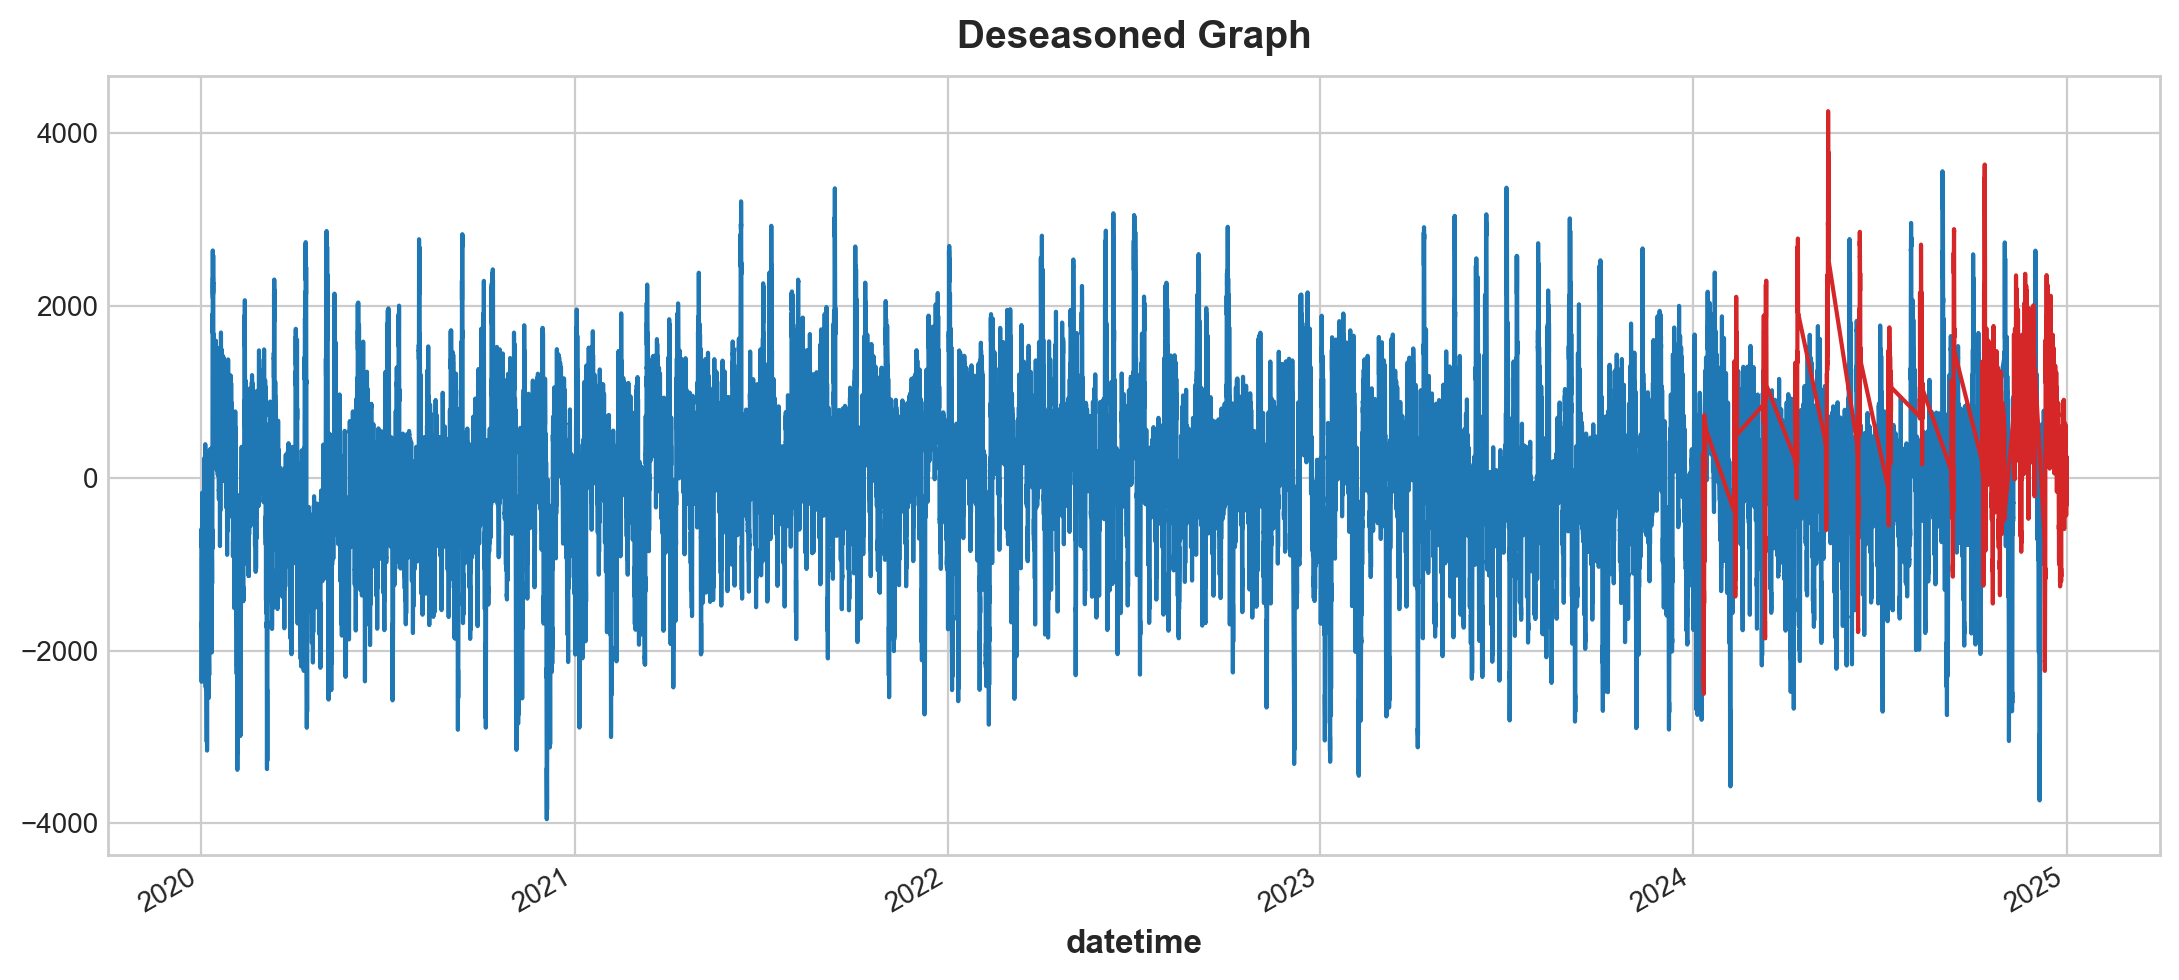

In [42]:
axs = y_deseasoned_fit.plot(
    color='C0', figsize=(11, 5), subplots=True, sharex=True,
    title=['Deseasoned Graph'],
)
axs = y_deseasoned_pred.plot(
    color='C3', subplots=True, sharex=True, ax=axs,
)
for ax in axs: ax.legend([])

In [43]:
y_resid = y_train - y_fit

In [480]:
y_resid

2020-01-01 00:00:00    2697.823885
2020-01-01 00:15:00    2682.075111
2020-01-01 00:30:00    2660.672845
2020-01-01 00:45:00    2639.243066
2020-01-01 01:00:00    2685.550178
                          ...     
2024-01-01 13:00:00   -1398.744857
2024-01-01 13:15:00   -1478.924009
2024-01-01 13:30:00   -1519.446846
2024-01-01 13:45:00   -1576.560766
2024-01-01 14:00:00   -1598.935614
Length: 140377, dtype: float64

In [481]:
X_train = pd.DataFrame(index=X_train.index)
X_test = pd.DataFrame(index=X_test.index)

In [482]:
X_train

""
datetime
2020-01-01 00:00:00
2020-01-01 00:15:00
2020-01-01 00:30:00
2020-01-01 00:45:00
2020-01-01 01:00:00
...
2024-01-01 13:00:00
2024-01-01 13:15:00
2024-01-01 13:30:00


In [440]:
X_train

""


In [499]:
from statsmodels.tsa.deterministic import DeterministicProcess, CalendarFourier

# Create Fourier terms matching your periodogram peaks
daily = CalendarFourier(freq='D', order=3)      # captures 24h, 12h, 8h cycles
weekly = CalendarFourier(freq='W', order=2)     # weekly + harmonic
annual = CalendarFourier(freq='A', order=6)     # annual + semiannual + quarterly + smaller peaks

dp = DeterministicProcess(
    index=data.index,
    constant=True,      # intercept
    order=1,            # linear trend
    seasonal=False,     # you already use Fourier → don't want dummy explosion
    additional_terms=[daily, weekly, annual],
    drop=True
)

X = dp.in_sample()


In [500]:
idx_train, idx_test = train_test_split(
    data.index, test_size=0.2, shuffle=False,
)

X_train, X_test = X.loc[idx_train, :], X.loc[idx_test, :]
#y_train, y_test = y.loc[idx_train], y.loc[idx_test]

In [458]:
X_train

,const,trend,"sin(1,freq=D)","cos(1,freq=D)","sin(2,freq=D)","cos(2,freq=D)","sin(3,freq=D)","cos(3,freq=D)","sin(1,freq=W-SUN)","cos(1,freq=W-SUN)",...,"sin(2,freq=A-DEC)","cos(2,freq=A-DEC)","sin(3,freq=A-DEC)","cos(3,freq=A-DEC)","sin(4,freq=A-DEC)","cos(4,freq=A-DEC)","sin(5,freq=A-DEC)","cos(5,freq=A-DEC)","sin(6,freq=A-DEC)","cos(6,freq=A-DEC)"
datetime,,,,,,,,,,,,,,,,,,,,,
2020-01-01 00:00:00,1.0,1.0,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000e+00,0.974928,-0.222521,...,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000
2020-01-01 00:15:00,1.0,2.0,0.065403,0.997859,0.130526,0.991445,0.195090,9.807853e-01,0.972805,-0.231627,...,0.000358,1.000000,0.000536,1.000000,0.000715,1.000000,0.000894,1.000000,0.001073,0.999999
2020-01-01 00:30:00,1.0,3.0,0.130526,0.991445,0.258819,0.965926,0.382683,9.238795e-01,0.970597,-0.240712,...,0.000715,1.000000,0.001073,0.999999,0.001431,0.999999,0.001788,0.999998,0.002146,0.999998
2020-01-01 00:45:00,1.0,4.0,0.195090,0.980785,0.382683,0.923880,0.555570,8.314696e-01,0.968304,-0.249776,...,0.001073,0.999999,0.001609,0.999999,0.002146,0.999998,0.002682,0.999996,0.003219,0.999995
2020-01-01 01:00:00,1.0,5.0,0.258819,0.965926,0.500000,0.866025,0.707107,7.071068e-01,0.965926,-0.258819,...,0.001431,0.999999,0.002146,0.999998,0.002861,0.999996,0.003576,0.999994,0.004292,0.999991
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-01-01 13:00:00,1.0,140309.0,-0.258819,-0.965926,0.500000,0.866025,-0.707107,-7.071068e-01,0.467269,0.884115,...,0.018597,0.999827,0.027893,0.999611,0.037187,0.999308,0.046478,0.998919,0.055764,0.998444
2024-01-01 13:15:00,1.0,140310.0,-0.321439,-0.946930,0.608761,0.793353,-0.831470,-5.555702e-01,0.475515,0.879708,...,0.018954,0.999820,0.028429,0.999596,0.037902,0.999281,0.047371,0.998877,0.056836,0.998384
2024-01-01 13:30:00,1.0,140311.0,-0.382683,-0.923880,0.707107,0.707107,-0.923880,-3.826834e-01,0.483719,0.875223,...,0.019312,0.999814,0.028966,0.999580,0.038617,0.999254,0.048264,0.998835,0.057907,0.998322


In [399]:
y_pred.head()

2024-01-01 14:15:00    3088.317731
2024-01-01 14:30:00    3049.199295
2024-01-01 14:45:00    3009.392873
2024-01-01 15:00:00    2968.859561
2024-01-01 15:15:00    2928.223315
dtype: float64

In [403]:
y_pred = pd.DataFrame(y_pred)

In [126]:
def plot_pacf(ts, lags=20, alpha=0.5):
    """
    Plot Partial AutoCorrelation Function (PACF) for a time series.
    """
    ts = ts.dropna()
    n = len(ts)

    # Compute PACF values
    pacf_vals = pacf(ts, nlags=lags, method='yw')

    # Calculate 95% confidence interval (no-correlation band)
    z = 1.2816  # for 95% confidence
    conf = z / np.sqrt(n)

    # Plot setup
    fig, ax = plt.subplots(figsize=(10, 4))
    sns.barplot(x=list(range(len(pacf_vals))), y=pacf_vals, color="C0", ax=ax)

    # Add symmetric confidence bands
    ax.fill_between(range(len(pacf_vals)),
                    conf, -conf,
                    color='C1', alpha=0.2)

    # Reference line at zero
    ax.axhline(0, color='black', linewidth=1)

    ax.set(
        title="Partial Autocorrelation Function (PACF)",
        xlabel="Lag",
        ylabel="Partial Autocorrelation",
    )
    ax.set_xticks(range(0, lags + 1))

    plt.tight_layout()
    #return fig

def lagplot(x, y=None, lag=1, standardize=False, ax=None, **kwargs):
    from matplotlib.offsetbox import AnchoredText
    x_ = x.shift(lag)
    if standardize:
        x_ = (x_ - x_.mean()) / x_.std()
    if y is not None:
        y_ = (y - y.mean()) / y.std() if standardize else y
    else:
        y_ = x
    corr = y_.corr(x_)
    if ax is None:
        fig, ax = plt.subplots()
    scatter_kws = dict(
        alpha=0.75,
        s=3,
    )
    line_kws = dict(color='C3', )
    ax = sns.regplot(x=x_,
                     y=y_,
                     scatter_kws=scatter_kws,
                     line_kws=line_kws,
                     lowess=True,
                     ax=ax,
                     **kwargs)
    at = AnchoredText(
        f"{corr:.2f}",
        prop=dict(size="large"),
        frameon=True,
        loc="upper left",
    )
    at.patch.set_boxstyle("square, pad=0.0")
    ax.add_artist(at)
    ax.set(title=f"Lag {lag}", xlabel=x_.name, ylabel=y_.name)
    return ax


def plot_lags(x, y=None, lags=6, nrows=1, lagplot_kwargs={}, **kwargs):
    import math
    kwargs.setdefault('nrows', nrows)
    kwargs.setdefault('ncols', math.ceil(lags / nrows))
    kwargs.setdefault('figsize', (kwargs['ncols'] * 2, nrows * 2 + 0.5))
    fig, axs = plt.subplots(sharex=True, sharey=True, squeeze=False, **kwargs)
    for ax, k in zip(fig.get_axes(), range(kwargs['nrows'] * kwargs['ncols'])):
        if k + 1 <= lags:
            ax = lagplot(x, y, lag=k + 1, ax=ax, **lagplot_kwargs)
            ax.set_title(f"Lag {k + 1}", fontdict=dict(fontsize=14))
            ax.set(xlabel="", ylabel="")
        else:
            ax.axis('off')
    plt.setp(axs[-1, :], xlabel=x.name)
    plt.setp(axs[:, 0], ylabel=y.name if y is not None else x.name)
    fig.tight_layout(w_pad=0.1, h_pad=0.1)
    return fig

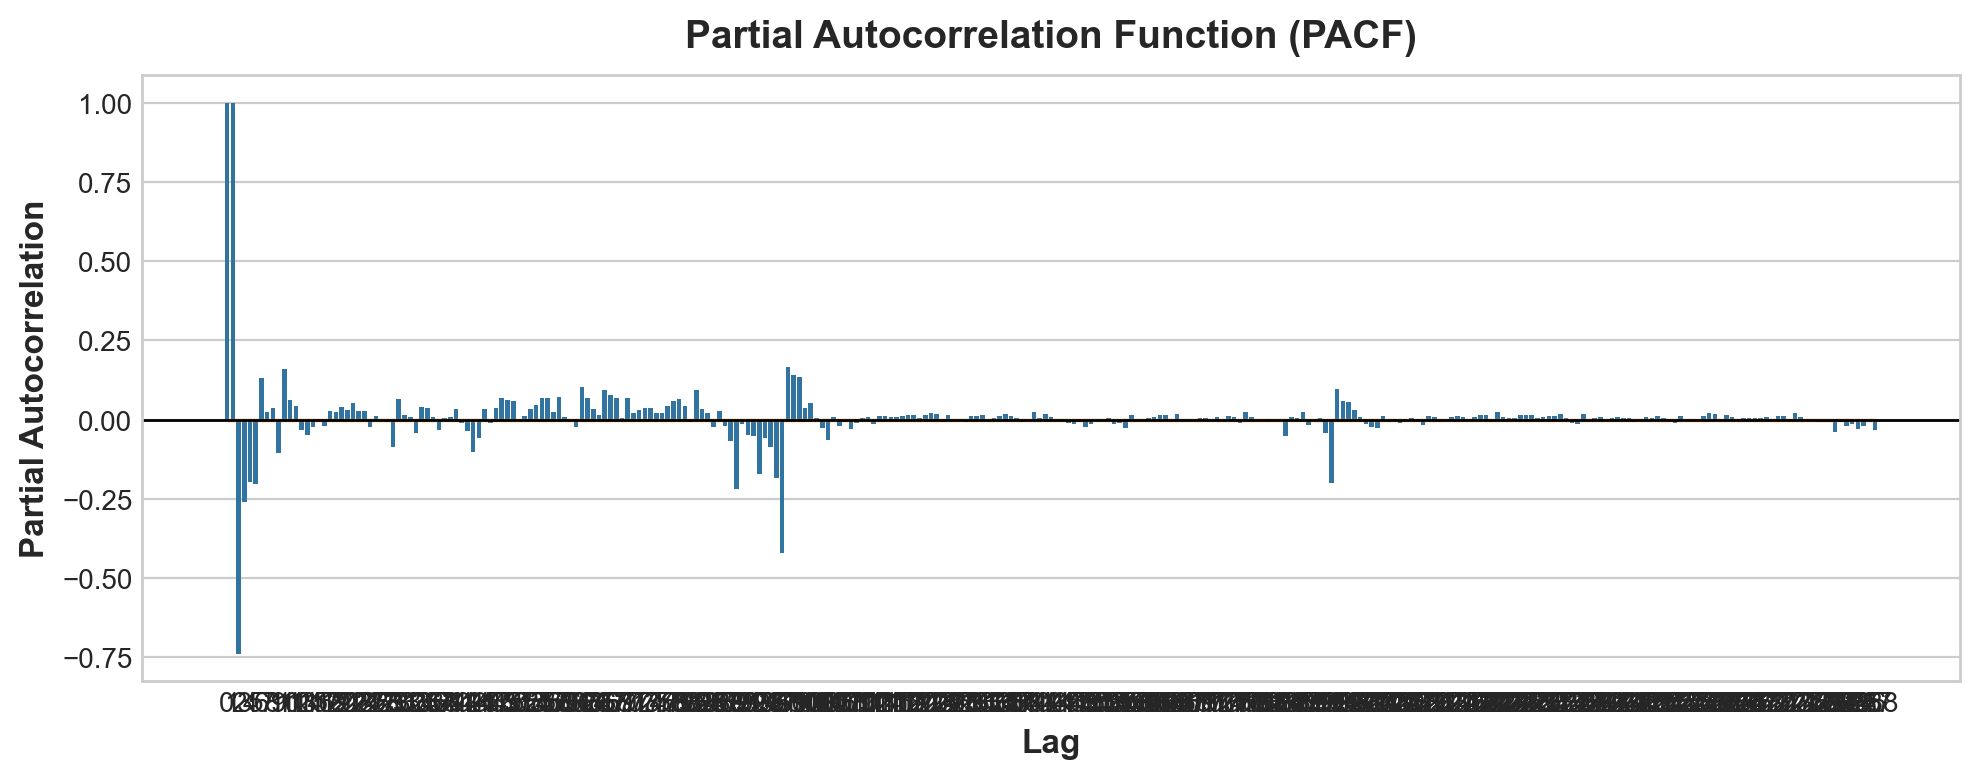

In [460]:
plot_pacf(data['Actual Total Load (MW)'], lags=72*4)

In [277]:
X1 = make_lags(y_deseasoned_fit, 24*4+1, 24*4+8).fillna(0.0)
X2 = make_lags(y_deseasoned_fit, 48*4+1, 48*4+8).fillna(0.0)
X3 = make_lags(y_deseasoned_fit, 72*4+1, 72*4+8).fillna(0.0)

In [278]:
Y = make_lags(y_deseasoned_fit, -24*4+1, 0).fillna(0.0)

In [279]:
x1 = make_lags(y_deseasoned_pred, 24*4+1, 24*4+8).fillna(0.0)
x2 = make_lags(y_deseasoned_pred, 48*4+1, 48*4+8).fillna(0.0)
x3 = make_lags(y_deseasoned_pred, 72*4+1, 72*4+8).fillna(0.0)

In [280]:
X_train = pd.concat([X_train,X1,X2,X3], axis = 1).fillna(0.0)
X_test = pd.concat([X_test,x1,x2,x3], axis = 1).fillna(0.0)
y_resid = Y.fillna(0.0)

In [51]:
X_train['week'] = X_train.index.week
X_train['day'] = X_train.index.dayofweek
X_test['week'] = X_test.index.week
X_test['day'] = X_test.index.dayofweek

C:\Users\as comp\AppData\Local\Temp\ipykernel_3644\7863795.py:1: FutureWarning: weekofyear and week have been deprecated, please use DatetimeIndex.isocalendar().week instead, which returns a Series. To exactly reproduce the behavior of week and weekofyear and return an Index, you may call pd.Int64Index(idx.isocalendar().week)
  X_train['week'] = X_train.index.week
C:\Users\as comp\AppData\Local\Temp\ipykernel_3644\7863795.py:3: FutureWarning: weekofyear and week have been deprecated, please use DatetimeIndex.isocalendar().week instead, which returns a Series. To exactly reproduce the behavior of week and weekofyear and return an Index, you may call pd.Int64Index(idx.isocalendar().week)
  X_test['week'] = X_test.index.week


In [503]:
X_train, y_pred = X_train.align(y_pred, join='inner', axis = 0)

In [501]:
y_resid = pd.DataFrame(y_resid)

In [504]:
y_resid

,0
2020-01-01 00:00:00,2697.823885
2020-01-01 00:15:00,2682.075111
2020-01-01 00:30:00,2660.672845
2020-01-01 00:45:00,2639.243066
2020-01-01 01:00:00,2685.550178
...,...
2024-01-01 13:00:00,-1398.744857
2024-01-01 13:15:00,-1478.924009
2024-01-01 13:30:00,-1519.446846
2024-01-01 13:45:00,-1576.560766


In [505]:
X_train

,const,trend,"sin(1,freq=D)","cos(1,freq=D)","sin(2,freq=D)","cos(2,freq=D)","sin(3,freq=D)","cos(3,freq=D)","sin(1,freq=W-SUN)","cos(1,freq=W-SUN)",...,"sin(2,freq=A-DEC)","cos(2,freq=A-DEC)","sin(3,freq=A-DEC)","cos(3,freq=A-DEC)","sin(4,freq=A-DEC)","cos(4,freq=A-DEC)","sin(5,freq=A-DEC)","cos(5,freq=A-DEC)","sin(6,freq=A-DEC)","cos(6,freq=A-DEC)"


In [52]:
#from sklearn.multioutput import MultiOutputRegressor
xgb = XGBRegressor()
xgb.fit(X_train, y_resid)

y_fit1 = pd.Series(xgb.predict(X_train), index = X_train.index)
y_pred1 = pd.Series(xgb.predict(X_test), index = X_test.index)

In [282]:
# 1. select first row of every day (every 96 steps)
y_fit_daily = y_fit1.iloc[::96]
y_pred_daily = y_pred1.iloc[::96]

# 2. create time offsets for each 96-step 15-minute forecast
freq = '15T'
horizon = y_fit1.shape[1]
offsets = pd.timedelta_range(start='0T', periods=horizon, freq=freq)

# 3. convert rows into a timestamp-indexed Series
def expand_forecast(df):
    series_list = []
    for ts, row in df.iterrows():
        idx = ts + offsets
        s = pd.Series(row.values, index=idx)
        series_list.append(s)
    return pd.concat(series_list)

# 4. expanded series
y_fit1 = expand_forecast(y_fit_daily)
y_pred1 = expand_forecast(y_pred_daily)


In [56]:
y_fit_boosted = y_fit1 + y_fit
y_pred_boosted = y_pred1 + y_pred

C:\Users\as comp\AppData\Local\Temp\ipykernel_3644\1459157978.py:11: UserWarning: When passing multiple axes, sharex and sharey are ignored. These settings must be specified when creating axes.
  axs = y_pred_boosted.plot(


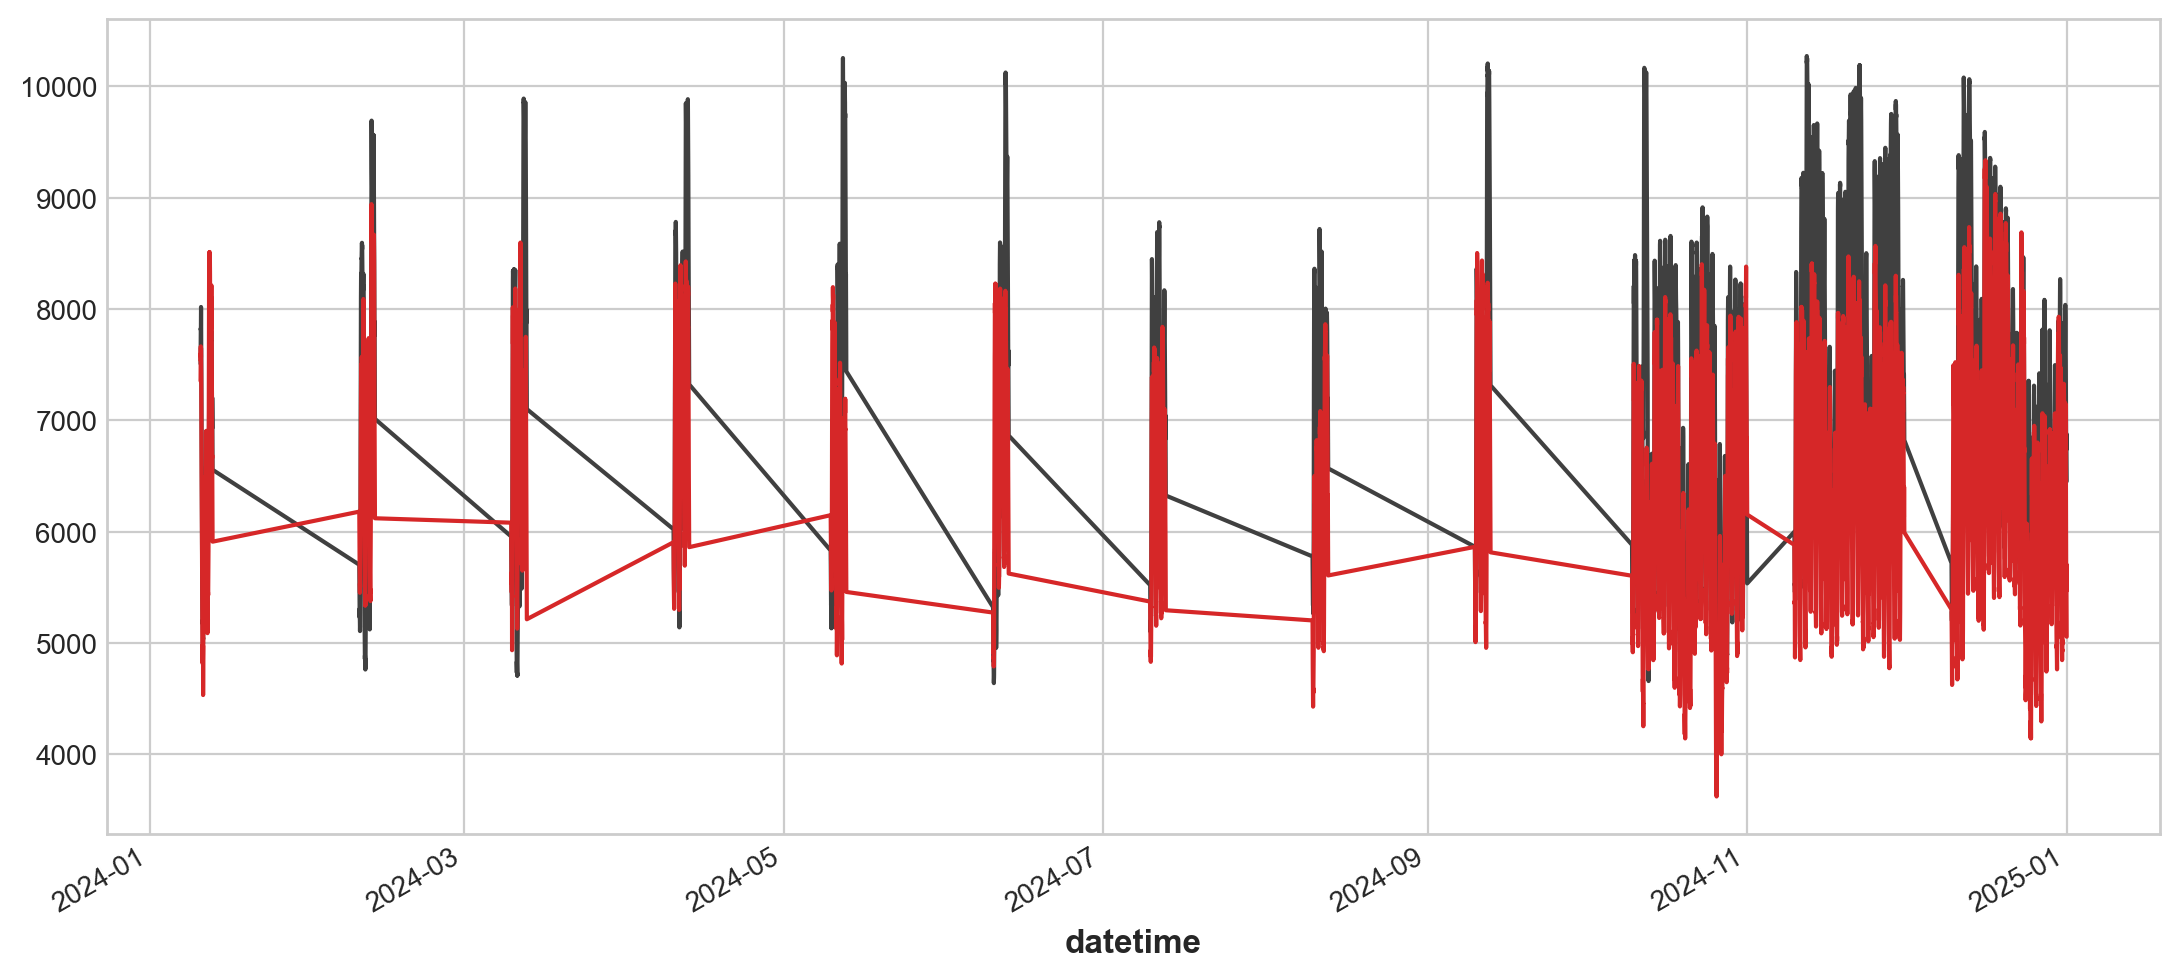

In [57]:
#axs = y_train.plot(
#    color='0.25', figsize=(11, 5), subplots=True, sharex=True,
#    title=['Hybrid Model Performance'],
#)
axs = y_test.plot(
    color='0.25', subplots=True, sharex=True, 
)
#axs = y_fit_boosted.plot(
#    color='C0', subplots=True, sharex=True, ax=axs,
#)
axs = y_pred_boosted.plot(
    color='C3', subplots=True, sharex=True, ax=axs,
)
for ax in axs: ax.legend([])

In [285]:
y_train, y_fit_boosted = y_train.align(y_fit, join='inner', axis = 0)
y_test, y_pred_boosted = y_train.align(y_fit, join='inner', axis = 0)

In [58]:
print("Mean Absolute Error: " + str(mean_absolute_error(y_train, y_fit_boosted)))

Mean Absolute Error: 173.02436567712212


In [59]:
print("Mean Absolute Error: " + str(mean_absolute_error(y_pred_boosted, y_test)))

Mean Absolute Error: 858.8824961660324
